In [45]:
from py_files.setup import *
setup_notebook()

import math

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. initial simulation

In [46]:
# 1. calibrate
m = CapIncModel()
m = CapIncModel_single()
out = m.calibrate(target_elas=m.phi)

# 2. pin baseline SS first
T=30; tau0=0.0; tauT=-0.1; rho=0.85; tail=25; tau_ss=0.0 
ss0 = m.solve_steady_state(tau=tau0)


 Calibrate household: zero wage premia + target eps_nI 
targets    prem=0, prem=0, eps=0.6
------------------------------------------------------------
old        mu=0.26   =>
           log(wI/wC)=-1.07e-02

old        phi=0.60 =>
           eps=0.445
------------------------------------------------------------
new        mu=0.2567   =>
           log(wI/wC)=-4.94e-14

new        phi=0.8072 =>
           eps=0.600



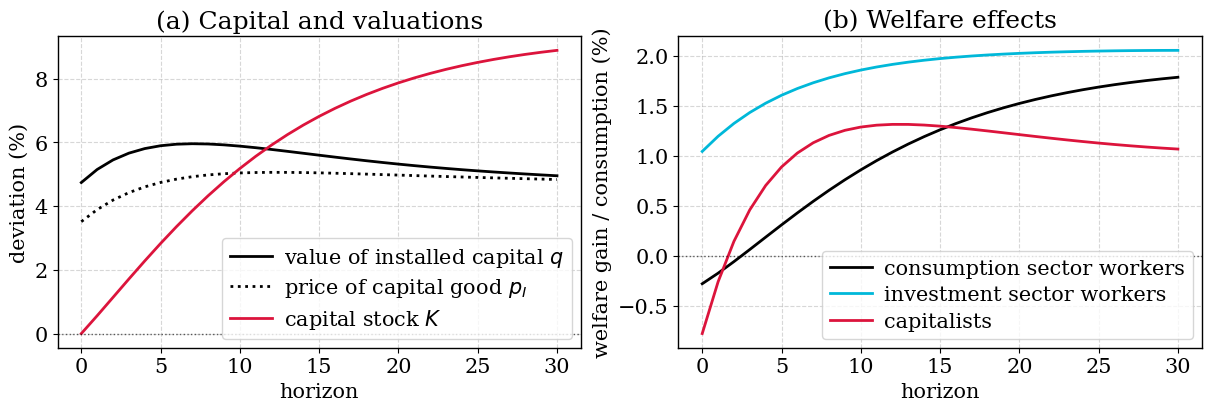

In [47]:
# 2. params and sim
net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc(
    T=T, tau0=tau0, tauT=tauT, rho=rho, tail=tail,
)

sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)

fig, (ax1, ax2), ss, sim = build_output_single.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
)


# fig, (ax1, ax2), ss, sim = build_output.welfare_effects(
#     m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
# )

In [48]:
res_elas = build_output_single.inc_elas(m, sim, tau=tau_ss) 


--------------------------------------------
 Incidence (share of total welfare gain) 
--------------------------------------------
Consumption workers     24.1%
Investment workers      51.4%
Capitalists             24.4%

--------------------------------------------
 Elasticities 
--------------------------------------------
epsS_LR        1.41
epsS_SR        0.12
epsD           1.38

--------------------------------------------
 Tax elasticities (LR GE) 
--------------------------------------------
price_elas     0.60
quant_elas     0.85
wealth_ela     1.45



In [49]:
# # 1. get empirical path
# net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc_emp(
#     tail=tail, normalized=True
# )

# tau0 = tau_long[0]

# # 2. pin baseline SS 
# ss0 = m.solve_steady_state(tau=tau0)

# # 3. simulate
# sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)

# # 4. plot
# fig, (ax1, ax2), ss, sim = build_output_single.welfare_effects(
#     m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
# )

In [50]:
# res_elas = build_output_single.inc_elas(m, sim, tau=tau_ss)

### 2. labour dynamics

*and assess the labour share*

In [51]:
# 1. initiate
gamma  = 0.8
T_solve = T + tail

# anchor baseline SS at tau0
ss0 = m.solve_steady_state(tau=tau0)
ss1 = m.solve_steady_state(tau=tauT)

In [52]:
# 1.paths
_, tau_t1_long, _, _ = shocks.perm_tc(T=T, tail=tail, tau0=tau0, tauT=tauT, rho=rho)
tau_t2_long = np.full_like(tau_t1_long, tau0)
tau_t3_long = np.full_like(tau_t1_long, tauT)
# _, tau_t4_long, _, _  = shocks.perm_tc_emp(tail=tail)

# 3. intial guesses
qg0 = np.full(T_solve + 1, ss0["q"])
qg1 = np.full(T_solve + 1, ss1["q"])

# 4. simulations
# 4.1 baseline ss
sim2 = m.solve_transition(tau_path=tau_t2_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tau0)
ls2_full = build_output_single.labour_share(m, sim2, gamma=gamma)

# 4.2 new ss
sim3 = m.solve_transition(tau_path=tau_t3_long, K0=ss1["K"],
                          q_guess_path=qg1, tau_terminal=tauT)
ls3_full = build_output_single.labour_share(m, sim3, gamma=gamma)

# 4.3 permanent shock
sim1 = m.solve_transition(tau_path=tau_t1_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tauT)
ls1_full = build_output_single.labour_share(m, sim1, gamma=gamma)

h = np.arange(T + 1)

/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_nonlin.py:374: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


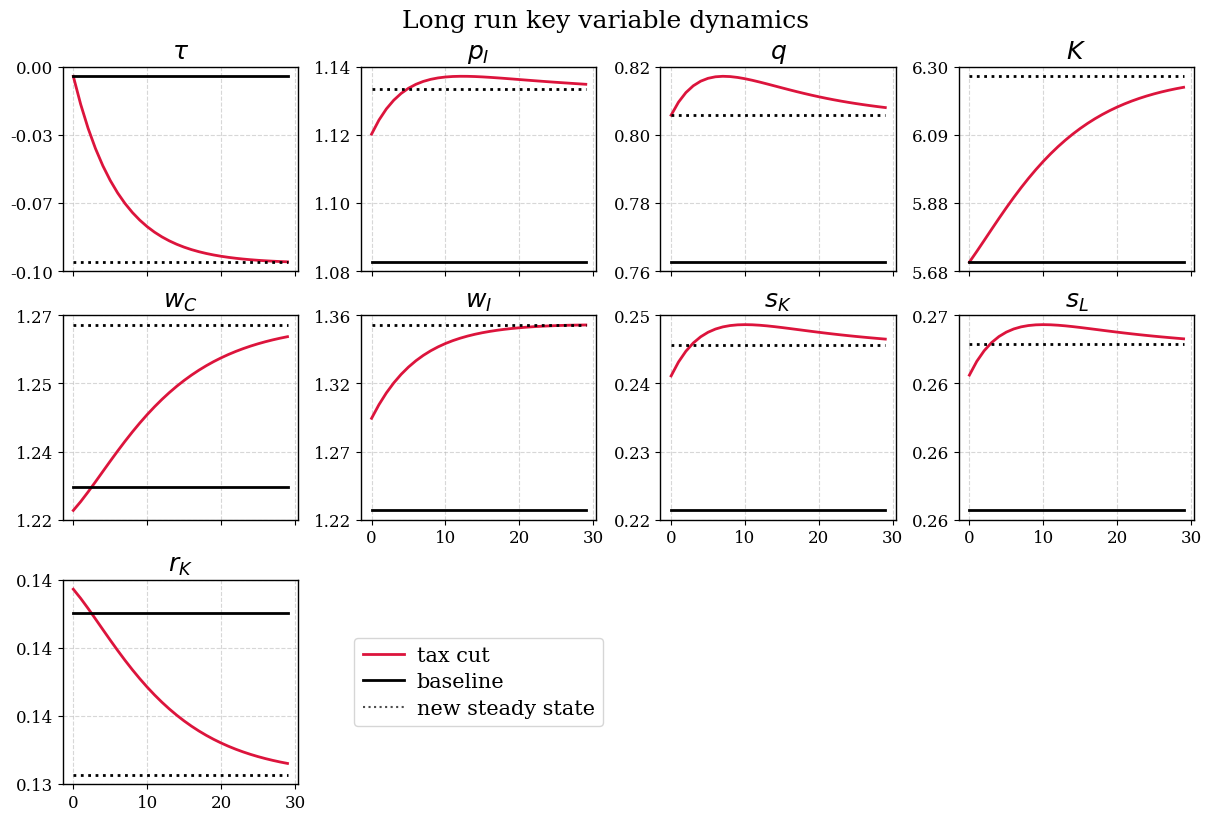

In [53]:
T_plot = T
h = np.arange(T_plot)

def trunc_pack(sim):
    return {k: np.asarray(v) for k, v in sim.items()}

S1 = trunc_pack({**sim1, **sim})
S2 = trunc_pack(sim2)
S3 = trunc_pack(sim3)

keys = [
    "tau", 'pI', 'q','K',
    "wC","wI","sK","sL",
    "rC_gross",
]
keys = [k for k in keys if k in S1 and k in S2]

ncols = 4
nrows = 3
        
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 2.7*nrows),
    sharex=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()
fig.suptitle('Long run key variable dynamics')

for i, k in enumerate(keys):
    ax = axes[i]
    y1 = S1[k][:T_plot]
    y2 = S2[k][:T_plot]
    y3 = S3[k][:T_plot]
    ax.plot(h, y1, lw=2, color="crimson")
    ax.plot(h, y2, lw=2, color="k")
    ax.plot(h, y3, lw=2, color="k", ls=":")
    ax.plot()
    
    ax.set_title(var_groups.model_var.get(k, k))
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis="y", labelsize=12)
    ax.tick_params(axis="x", labelsize=12)

for j in range(len(keys), len(axes)):
    axes[j].set_axis_off()

# if len(keys) < len(axes):
    ax_leg = axes[len(keys)]
    ax_leg.set_axis_off()
    h1 = plt.Line2D([0], [0], color="crimson", lw=2)
    h2 = plt.Line2D([0], [0], color="k",       lw=2)
    h3 = plt.Line2D([0], [0], color="k", lw=1.5, ls=":", alpha=0.7)
    ax_leg.legend([h1, h2, h3], ["tax cut", "baseline", "new steady state"],
                loc="center", frameon=True)

for col in range(ncols):
    # find the last active (visible) axis in this column
    col_axes = [axes[row * ncols + col] for row in range(nrows)
                if row * ncols + col < len(axes)]
    active = [ax for ax in col_axes if ax.get_visible() and ax.axison]
    if active:
        active[-1].tick_params(axis='x', labelbottom=True)

# plt.savefig('0_output/sim_lr_cs.png', dpi=200)
plt.show()

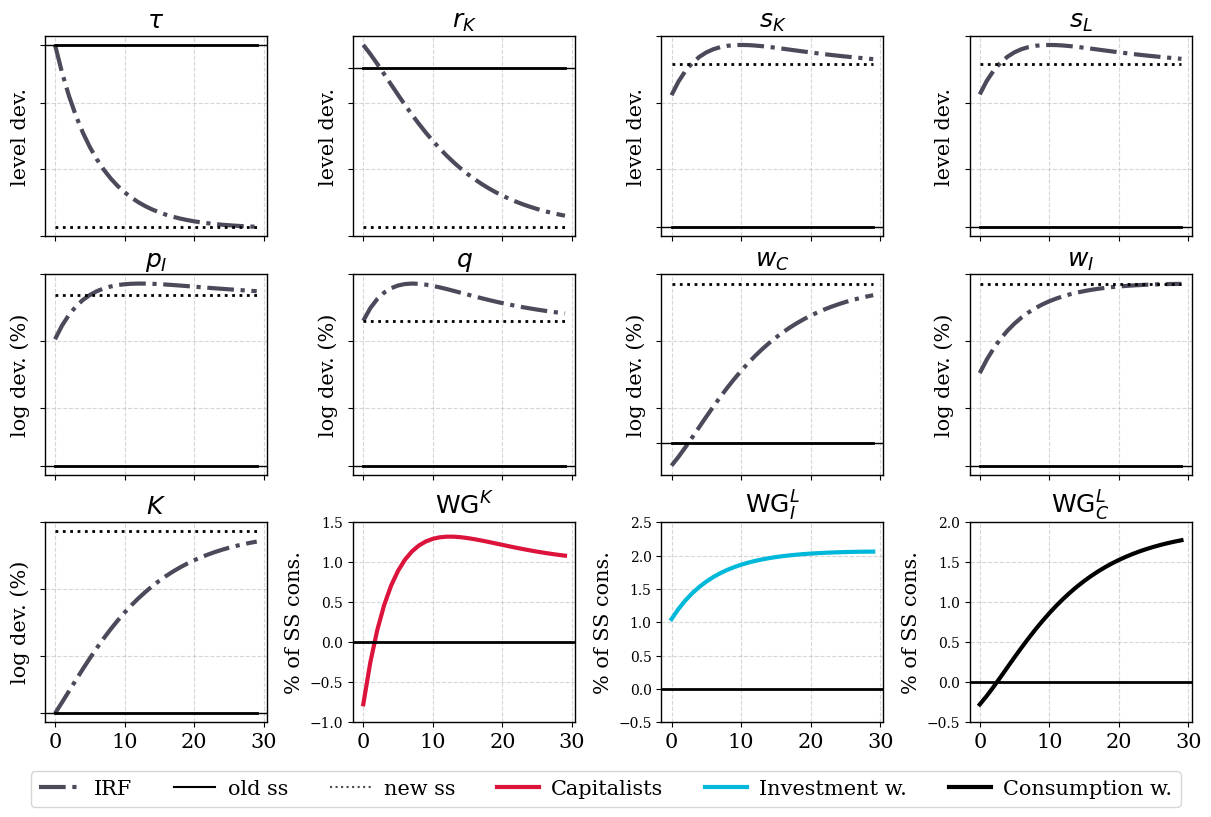

In [54]:

# ── colour configuration ─────────────────────────────────────────
IRF_COLOR = "#4A4A5A"   # colour for all standard IRF panels

COLOR_C   = "k"         # consumption workers
COLOR_I   = "#00B8D9"   # investment workers
COLOR_K   = "crimson"   # capitalists
# ─────────────────────────────────────────────────────────────────

welfare_colors = {"wg_C": COLOR_C, "wg_I": COLOR_I, "wg_K": COLOR_K}

T_plot = T
h = np.arange(T_plot)

def trunc_pack(sim):
    return {k: np.asarray(v) for k, v in sim.items()}

S1 = trunc_pack({**sim1, **sim})
S2 = trunc_pack(sim2)
S3 = trunc_pack(sim3)

keys = [
    "tau", "rC_gross", "sK", "sL",
    'pI', 'q', "wC", "wI",
    'K',
]
keys = [k for k in keys if k in S1 and k in S2]

welfare_keys = [
    ("wg_K", r"$\text{WG}^K$"),
    ("wg_I", r"$\text{WG}^L_I$"),
    ("wg_C", r"$\text{WG}^L_C$"),
]

log_dev_keys = {'pI', 'q', 'K', 'I', 'C', 'wC', 'wI'}

def to_log_dev(series, baseline_series):
    ss_val = float(baseline_series[0])
    return 100.0 * np.log(np.asarray(series, float) / ss_val)

def to_level_dev(series, baseline_series):
    ss_val = float(baseline_series[0])
    return np.asarray(series, float) - ss_val

C_ss = float(S2["C"][0])

all_keys  = keys + [wk for wk, _ in welfare_keys]
ncols     = 4
nrows     = 3

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 2.5 * nrows),
    sharex=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()

for j in range(len(keys), len(axes)):
    h1 = plt.Line2D([0], [0], color="#4A4A5A",lw=3, ls='-.')
    h2 = plt.Line2D([0], [0], color="k",      lw=1.5)
    h3 = plt.Line2D([0], [0], color="k",      lw=1.5, ls=":", alpha=0.7)
    h4_K = plt.Line2D([0], [0], color=COLOR_K, lw=3, ls="-")
    h4_I = plt.Line2D([0], [0], color=COLOR_I, lw=3, ls="-")
    h4_C = plt.Line2D([0], [0], color=COLOR_C, lw=3, ls="-")

# --- standard variable panels ---
for i, k in enumerate(keys):
    ax = axes[i]
    raw1 = S1[k][:T_plot]
    raw2 = S2[k][:T_plot]
    raw3 = S3[k][:T_plot]

    if k in log_dev_keys:
        y1 = to_log_dev(raw1, raw2)
        y2 = to_log_dev(raw2, raw2)
        y3 = to_log_dev(raw3, raw2)
        ylabel = "log dev. (%)"
    else:
        y1 = to_level_dev(raw1, raw2)
        y2 = to_level_dev(raw2, raw2)
        y3 = to_level_dev(raw3, raw2)
        ylabel = "level dev."

    ax.plot(h, y1, lw=3, color=IRF_COLOR, ls='-.')
    ax.plot(h, y2, lw=2, color="k")
    ax.plot(h, y3, lw=2, color="k", ls=":")
    ax.axhline(0, color="k", lw=1, ls="-")
    ax.set_title(var_groups.model_var.get(k, k))
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis="x")

    ticks = ax.get_yticks()
    ticks[np.argmin(np.abs(ticks))] = 0.0
    ax.set_yticks(ticks)
    ax.set_yticklabels([])

# --- welfare panels ---
for j, (wk, title) in enumerate(welfare_keys):
    ax = axes[len(keys) + j]

    path = 100.0 * np.asarray(S1[wk], float)[:T_plot] / C_ss

    ax.plot(h, path, lw=3, color=welfare_colors[wk])
    ax.axhline(0, color="k", lw=2, ls="-")
    ax.set_title(title)
    ax.set_ylabel("% of SS cons.")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x")

    ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
    ticks = ax.get_yticks()
    ticks[np.argmin(np.abs(ticks))] = 0.0
    ax.set_yticks(ticks)

# --- legend + turn off unused axes ---
fig.legend(
    [h1, h2, h3, h4_K, h4_I, h4_C],
    ["IRF", "old ss", "new ss",
     "Capitalists", r"Investment w.", r"Consumption w."],
    loc="lower center", ncol=6, frameon=True,
    bbox_to_anchor=(0.5, -0.08),
)

# --- x-axis labels on bottom active row per column ---
for col in range(ncols):
    col_axes = [axes[row * ncols + col] for row in range(nrows)
                if row * ncols + col < len(axes)]
    active = [ax for ax in col_axes if ax.get_visible() and ax.axison]
    if active:
        active[-1].tick_params(axis='x', labelbottom=True)

plt.savefig('0_output/sim_lr_cs.png', dpi=200)
plt.show()